In [58]:
# imports and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import re
import html
import unicodedata
import warnings
import time

from scipy.stats import spearmanr

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    average_precision_score,
    roc_auc_score
)
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    make_scorer,
    median_absolute_error,
    explained_variance_score,
)
from scipy.stats import spearmanr, pearsonr
from xgboost import XGBRegressor


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)


In [59]:
# find the raw json files

# path I use locally
json_dir = Path("../../raw_new")

# fallback when running in this notebook environment
if not json_dir.exists():
    json_dir = Path("/mnt/data")

# keep comment batches only; skip the tracker metadata file
json_files = sorted([
    p for p in json_dir.glob("*.json")
    if "scraped_videos_tracker" not in p.name
])

print("JSON directory:", json_dir.resolve())
print("Number of JSON files found:", len(json_files))
print([p.name for p in json_files[:5]])


JSON directory: /Users/hargun/Desktop/data-science/EarlySlangDetection/raw_new
Number of JSON files found: 75
['1STUD_batch_20260615_220936.json', '1STUD_batch_20260616_120929.json', '1STUD_batch_20260616_125913.json', '1STUD_batch_20260629_221901.json', 'AsmonTV_batch_20260608_205250.json']


In [60]:
# load the raw comment files

dfs = []

for json_file in json_files:
    temp = pd.read_json(json_file)

    # Example filename:
    #   MrBeastGaming_batch_20260608_205250.json
    # We extract:
    #   MrBeastGaming
    temp["channel_name"] = json_file.stem.split("_batch_")[0].replace("(1)", "")

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# basic cleanup
df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
df["likes"] = pd.to_numeric(df["likes"], errors="coerce").fillna(0).clip(lower=0).astype(int)
df["text"] = df["text"].fillna("").astype(str)

# no timestamp means no week assignment
df = df.dropna(subset=["published_at"]).reset_index(drop=True)

# simple comment id after cleaning
df["comment_id"] = df.index

display(df.head())
display(df.info())

print("Raw comments:", len(df))
print("Unique videos:", df["video_id"].nunique())
print("Unique channels:", df["channel_name"].nunique())


,video_id,text,likes,published_at,channel_name,comment_id
0,BSv6hna2Ycs,3:22 zenin clan treatment,49,2026-06-15 11:44:27+00:00,1STUD,0
1,BSv6hna2Ycs,your goat stud i wacht you 4 years,29,2026-06-15 11:03:58+00:00,1STUD,1
2,BSv6hna2Ycs,I WATCHED YA FOR 2 YEARS!!!,6,2026-06-15 12:03:19+00:00,1STUD,2
3,BSv6hna2Ycs,2:21 Bro Noob Army Being Like God Slayer😂,3,2026-06-15 14:31:33+00:00,1STUD,3
4,BSv6hna2Ycs,Yo stud even though you probably not going to ...,3,2026-06-15 14:24:59+00:00,1STUD,4


<class 'pandas.DataFrame'>
RangeIndex: 1739328 entries, 0 to 1739327
Data columns (total 6 columns):
 #   Column        Dtype              
---  ------        -----              
 0   video_id      str                
 1   text          str                
 2   likes         int64              
 3   published_at  datetime64[us, UTC]
 4   channel_name  str                
 5   comment_id    int64              
dtypes: datetime64[us, UTC](1), int64(2), str(3)
memory usage: 79.6 MB


None

Raw comments: 1739328
Unique videos: 19517
Unique channels: 32


In [61]:
NUM_WEEKS = 20
FUTURE_WEEKS = 3

# assign each comment to a week

latest = df["published_at"].max()

# week_back = 0 means most recent week.
# week_back = 1 means one week before the most recent week.
df["week_back"] = ((latest - df["published_at"]).dt.days // 7).astype(int)

# keep the most recent 20 weeks
df = df[(df["week_back"] >= 0) & (df["week_back"] < NUM_WEEKS)].copy().reset_index(drop=True)

# reset ids after filtering
df["comment_id"] = df.index

# make time_id run from old -> new
df["time_id"] = df["week_back"].max() - df["week_back"]

display(df[["comment_id", "published_at", "week_back", "time_id", "text", "likes"]].head())

print("Comments in 20-week window:", len(df))
print("time_id range:", df["time_id"].min(), "to", df["time_id"].max())


,comment_id,published_at,week_back,time_id,text,likes
0,0,2026-06-15 11:44:27+00:00,2,17,3:22 zenin clan treatment,49
1,1,2026-06-15 11:03:58+00:00,2,17,your goat stud i wacht you 4 years,29
2,2,2026-06-15 12:03:19+00:00,2,17,I WATCHED YA FOR 2 YEARS!!!,6
3,3,2026-06-15 14:31:33+00:00,2,17,2:21 Bro Noob Army Being Like God Slayer😂,3
4,4,2026-06-15 14:24:59+00:00,2,17,Yo stud even though you probably not going to ...,3


Comments in 20-week window: 373517
time_id range: 0 to 19


In [62]:
# tokenize comments

TOKEN_RE = re.compile(
    r"""
    (?<![a-z0-9])
    \#?
    (?:
        [a-z]+(?:['’‘ʼ`´＇-][a-z]+)*[a-z0-9]*
        |
        [a-z]*\d+[a-z0-9]*
    )
    (?![a-z0-9])
    """,
    re.I | re.VERBOSE
)

URL_RE = re.compile(r"https?://\S+|www\.\S+")
TIME_RE = re.compile(r"\b\d{1,2}:\d{2}(?::\d{2})?\b")

APOSTROPHE_TRANSLATION = str.maketrans({
    "’": "'",
    "‘": "'",
    "ʼ": "'",
    "`": "'",
    "´": "'",
    "＇": "'"
})

def tokenize(text):
    """Basic tokenizer for comment text."""
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(APOSTROPHE_TRANSLATION)
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = TIME_RE.sub(" ", text)

    tokens = [m.group(0).lstrip("#") for m in TOKEN_RE.finditer(text)]

    # Remove tokens that are only digits
    tokens = [t for t in tokens if not t.isdigit()]

    return tokens

df["tokens"] = df["text"].apply(tokenize)

display(df[["text", "tokens"]].sample(10, random_state=42))


,text,tokens
115493,Day 7 of asking for a fractal block world theory,"[day, of, asking, for, a, fractal, block, worl..."
247243,Interesting,[interesting]
179793,“as of 2024” okay. so wheres the updated chart?,"[as, of, okay, so, wheres, the, updated, chart]"
329339,"Ryan Cohen, trust the process","[ryan, cohen, trust, the, process]"
370479,Hissan wouldve captured this guy easy once the...,"[hissan, wouldve, captured, this, guy, easy, o..."
175703,Imagine jumping as a casual Morse code for bei...,"[imagine, jumping, as, a, casual, morse, code,..."
256504,The whole game in one trailer!!! Nice,"[the, whole, game, in, one, trailer, nice]"
157569,28:37 TIMMEH????,[timmeh]
362904,We’ve seen this already bro ♻️,"[we've, seen, this, already, bro]"
194213,Continue Playing Red Dead Redemption 2 we all ...,"[continue, playing, red, dead, redemption, we,..."


In [63]:
# one word per comment

df_words = df.explode("tokens").rename(columns={"tokens": "word"})
df_words = df_words.dropna(subset=["word"])
df_words = df_words[df_words["word"].str.len() > 0].copy()

# count a word only once per comment
df_unique = df_words.drop_duplicates(["comment_id", "word", "time_id"])

display(df_words[["comment_id", "word", "likes", "time_id", "video_id"]].head())
display(df_unique[["comment_id", "word", "likes", "time_id", "video_id"]].head())

print("Word occurrences before de-duplication:", len(df_words))
print("Unique comment-word-week rows after de-duplication:", len(df_unique))


,comment_id,word,likes,time_id,video_id
0,0,zenin,49,17,BSv6hna2Ycs
0,0,clan,49,17,BSv6hna2Ycs
0,0,treatment,49,17,BSv6hna2Ycs
1,1,your,29,17,BSv6hna2Ycs
1,1,goat,29,17,BSv6hna2Ycs


,comment_id,word,likes,time_id,video_id
0,0,zenin,49,17,BSv6hna2Ycs
0,0,clan,49,17,BSv6hna2Ycs
0,0,treatment,49,17,BSv6hna2Ycs
1,1,your,29,17,BSv6hna2Ycs
1,1,goat,29,17,BSv6hna2Ycs


Word occurrences before de-duplication: 4765317
Unique comment-word-week rows after de-duplication: 4252512


In [64]:
# --------------------------------------------------
# Build stopword list
# --------------------------------------------------

stopwords = set("""
a about above after again against all am an and any are as at be because been before being below between both but by
can cannot could did do does doing down during each few for from further had has have having he her here hers herself
him himself his how i if in into is it its itself just me more most my myself no nor not of off on once only or other
our ours ourselves out over own same she should so some such than that the their theirs them themselves then there
these they this those through to too under until up very was we were what when where which while who whom why will
with you your yours yourself yourselves
""".split())

stopwords |= {
    "i'm","it's","that's","don't","you're","he's","she's","we're","they're",
    "i've","you've","we've","they've","i'll","you'll","we'll","they'll",
    "isn't","aren't","wasn't","weren't","can't","couldn't","wouldn't",
    "shouldn't","won't","didn't","doesn't","haven't","hasn't","hadn't",
    "there's","what's","who's","where's","when's","why's","how's",
    "im","ive","dont","cant","wont","youre","thats","theres","whats",
    "hes","shes","were","theyre","ll","re","ve","ur","amp"
}

stopwords |= {
    "would","one","get","even","video","go","know","never","got","good",
    "make","made","see","think","really","still","also","much","going",
    "people","bro","man","guys","time","way","back","first","last",
    "like","game","person","now","years","guy","kid","thing","stuff",
    "day","watch","look","looks","say","said","right","actually"
}



In [65]:

# Build one-row-per-word feature table 

weeks = list(range(NUM_WEEKS))

feature_weeks = list(range(NUM_WEEKS - FUTURE_WEEKS))

future_weeks = list(range(NUM_WEEKS - FUTURE_WEEKS, NUM_WEEKS))

eps_count = 1.0
eps_rel = 1e-10


weekly_comments = (
    df.groupby("time_id")["comment_id"]
    .nunique()
    .reindex(weeks)
    .fillna(0)
)

weekly_likes = (
    df.groupby("time_id")["likes"]
    .sum()
    .reindex(weeks)
    .fillna(0)
)


# Helper to make word x week matrices
def word_week_matrix(values=None, aggfunc="size"):
    if aggfunc == "size":
        mat = (
            df_unique
            .groupby(["word", "time_id"])
            .size()
            .unstack("time_id")
        )
    else:
        mat = (
            df_unique
            .pivot_table(
                index="word",
                columns="time_id",
                values=values,
                aggfunc=aggfunc
            )
        )

    mat = mat.reindex(columns=weeks).fillna(0)
    return mat


# Raw word-week matrices
count_mat = word_week_matrix(aggfunc="size")
likes_mat = word_week_matrix(values="likes", aggfunc="sum")
avg_likes_mat = word_week_matrix(values="likes", aggfunc="mean")
n_videos_mat = word_week_matrix(values="video_id", aggfunc=pd.Series.nunique)
n_channels_mat = word_week_matrix(values="channel_name", aggfunc=pd.Series.nunique)

avg_likes_mat = avg_likes_mat.fillna(0)
n_videos_mat = n_videos_mat.fillna(0)
n_channels_mat = n_channels_mat.fillna(0)

# Relative frequency and relative likes
rel_freq_mat = count_mat.div(weekly_comments.replace(0, np.nan), axis=1).fillna(0)
rel_likes_mat = likes_mat.div(weekly_likes.replace(0, np.nan), axis=1).fillna(0)


# Filter words
before_words = len(count_mat)

valid_words = [
    w for w in count_mat.index
    if (w not in stopwords) and (len(w) >= 2 or w in {"w", "l"})
]

count_mat = count_mat.loc[valid_words]
likes_mat = likes_mat.loc[valid_words]
avg_likes_mat = avg_likes_mat.loc[valid_words]
n_videos_mat = n_videos_mat.loc[valid_words]
n_channels_mat = n_channels_mat.loc[valid_words]
rel_freq_mat = rel_freq_mat.loc[valid_words]
rel_likes_mat = rel_likes_mat.loc[valid_words]

# keep words that appear at least 5 times in at least one week
keep_words = count_mat.index[count_mat.max(axis=1) >= 5]

count_mat = count_mat.loc[keep_words]
likes_mat = likes_mat.loc[keep_words]
avg_likes_mat = avg_likes_mat.loc[keep_words]
n_videos_mat = n_videos_mat.loc[keep_words]
n_channels_mat = n_channels_mat.loc[keep_words]
rel_freq_mat = rel_freq_mat.loc[keep_words]
rel_likes_mat = rel_likes_mat.loc[keep_words]

print("Unique words before filtering:", before_words)
print("Unique words after filtering:", len(keep_words))


# Make one wide dataframe
wide_parts = []

for name, mat in {
    "count": count_mat,
    "likes": likes_mat,
    "avg_likes": avg_likes_mat,
    "n_videos": n_videos_mat,
    "n_channels": n_channels_mat,
    "rel_freq": rel_freq_mat,
    "rel_likes": rel_likes_mat,
}.items():
    temp = mat.copy()
    temp.columns = [f"week_{i}_{name}" for i in temp.columns]
    wide_parts.append(temp)

wide = pd.concat(wide_parts, axis=1).fillna(0)

print("wide shape:", wide.shape)


# Target y
# X uses feature_weeks
# y uses future_weeks
past_rel_cols = [f"week_{i}_rel_freq" for i in feature_weeks]
future_rel_cols = [f"week_{i}_rel_freq" for i in future_weeks]

past_avg = wide[past_rel_cols].mean(axis=1)
future_avg = wide[future_rel_cols].mean(axis=1)

y = np.log((future_avg + eps_rel) / (past_avg + eps_rel))


# Build X from feature_weeks only
features = {}

base_vars = [
    "count",
    "likes",
    "avg_likes",
    "n_videos",
    "n_channels",
    "rel_freq",
    "rel_likes",
]

# raw histories
for var in base_vars:
    for i in feature_weeks:
        features[f"week_{i}_{var}"] = wide[f"week_{i}_{var}"]

# log growth features
for var in ["count", "likes", "avg_likes", "n_videos", "n_channels"]:
    for i in feature_weeks[1:]:
        features[f"{var}_log_growth_{i}_{i-1}"] = np.log(
            (wide[f"week_{i}_{var}"] + eps_count)
            / (wide[f"week_{i-1}_{var}"] + eps_count)
        )

for var in ["rel_freq", "rel_likes"]:
    for i in feature_weeks[1:]:
        features[f"{var}_log_growth_{i}_{i-1}"] = np.log(
            (wide[f"week_{i}_{var}"] + eps_rel)
            / (wide[f"week_{i-1}_{var}"] + eps_rel)
        )

# likes per comment
for i in feature_weeks:
    features[f"likes_per_comment_{i}"] = (
        wide[f"week_{i}_likes"] / (wide[f"week_{i}_count"] + eps_count)
    )

# summary features
count_cols = [f"week_{i}_count" for i in feature_weeks]
rel_cols = [f"week_{i}_rel_freq" for i in feature_weeks]
like_cols = [f"week_{i}_likes" for i in feature_weeks]
video_cols = [f"week_{i}_n_videos" for i in feature_weeks]
channel_cols = [f"week_{i}_n_channels" for i in feature_weeks]

features["weeks_nonzero"] = (wide[count_cols] > 0).sum(axis=1)

features["count_mean"] = wide[count_cols].mean(axis=1)
features["count_std"] = wide[count_cols].std(axis=1)
features["count_max"] = wide[count_cols].max(axis=1)

features["rel_freq_mean"] = wide[rel_cols].mean(axis=1)
features["rel_freq_std"] = wide[rel_cols].std(axis=1)
features["rel_freq_max"] = wide[rel_cols].max(axis=1)

features["likes_mean"] = wide[like_cols].mean(axis=1)
features["likes_std"] = wide[like_cols].std(axis=1)
features["likes_max"] = wide[like_cols].max(axis=1)

features["n_videos_mean"] = wide[video_cols].mean(axis=1)
features["n_videos_max"] = wide[video_cols].max(axis=1)

# recent momentum
recent_weeks = feature_weeks[-3:]
prev_weeks = feature_weeks[-6:-3]

features["rel_freq_recent3_mean"] = wide[[f"week_{i}_rel_freq" for i in recent_weeks]].mean(axis=1)
features["rel_freq_prev3_mean"] = wide[[f"week_{i}_rel_freq" for i in prev_weeks]].mean(axis=1)
features["rel_freq_momentum_3w"] = (
    features["rel_freq_recent3_mean"] - features["rel_freq_prev3_mean"]
)

features["likes_recent3_mean"] = wide[[f"week_{i}_likes" for i in recent_weeks]].mean(axis=1)
features["likes_prev3_mean"] = wide[[f"week_{i}_likes" for i in prev_weeks]].mean(axis=1)
features["likes_momentum_3w"] = (
    features["likes_recent3_mean"] - features["likes_prev3_mean"]
)

# slopes
week_nums = np.array(feature_weeks)

def slope(row):
    return np.polyfit(week_nums, row.values, 1)[0]

features["rel_freq_slope"] = wide[rel_cols].apply(slope, axis=1)
features["count_slope"] = wide[count_cols].apply(slope, axis=1)
features["likes_slope"] = wide[like_cols].apply(slope, axis=1)

X = pd.DataFrame(features, index=wide.index)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y summary:")
print(y.describe())

Unique words before filtering: 102964
Unique words after filtering: 11003
wide shape: (11003, 140)
X shape: (11003, 269)
y shape: (11003,)
y summary:
count    11003.000000
mean        -2.510809
std          4.901129
min        -16.230565
25%         -1.806201
50%         -0.697033
75%         -0.052784
max         16.050188
dtype: float64


In [66]:
def spearman_score(y_true, y_pred):
    return spearmanr(y_true, y_pred).statistic

def pearson_score(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "linear": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),

    "ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),

    "lasso": make_pipeline(
        StandardScaler(),
        Lasso(alpha=0.001, max_iter=10000)
    ),

    "random_forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "extra_trees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "hist_gradient_boosting": HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        random_state=42
    ),

    "xgboost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=600,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        n_jobs=-1
    ),

    "mlp_small": make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            batch_size=128,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        )
    ),

    "mlp_large": make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(256, 128, 64),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=5e-4,
            batch_size=128,
            max_iter=600,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        )
    ),
}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "medae": make_scorer(
        median_absolute_error,
        greater_is_better=False
    ),
    "r2": "r2",
    "explained_variance": make_scorer(
        explained_variance_score
    ),
    "spearman": make_scorer(spearman_score),
    "pearson": make_scorer(pearson_score),
}

rows = []

for name, model in models.items():

    print(f"Training {name}...")

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    rows.append({
        "model": name,

        "train_rmse_mean": -scores["train_rmse"].mean(),
        "train_rmse_std": scores["train_rmse"].std(),

        "test_rmse_mean": -scores["test_rmse"].mean(),
        "test_rmse_std": scores["test_rmse"].std(),

        "test_mae_mean": -scores["test_mae"].mean(),
        "test_mae_std": scores["test_mae"].std(),

        "test_median_ae_mean": -scores["test_medae"].mean(),
        "test_median_ae_std": scores["test_medae"].std(),

        "test_r2_mean": scores["test_r2"].mean(),
        "test_r2_std": scores["test_r2"].std(),

        "test_explained_variance_mean": scores["test_explained_variance"].mean(),
        "test_explained_variance_std": scores["test_explained_variance"].std(),

        "test_spearman_mean": scores["test_spearman"].mean(),
        "test_spearman_std": scores["test_spearman"].std(),

        "test_pearson_mean": scores["test_pearson"].mean(),
        "test_pearson_std": scores["test_pearson"].std(),
    })

cv_results = (
    pd.DataFrame(rows)
    .sort_values("test_spearman_mean", ascending=False)
    .reset_index(drop=True)
)

cv_results


Training linear...
Training ridge...
Training lasso...
Training random_forest...
Training extra_trees...
Training hist_gradient_boosting...
Training xgboost...
Training mlp_small...
Training mlp_large...


,model,train_rmse_mean,train_rmse_std,test_rmse_mean,test_rmse_std,test_mae_mean,test_mae_std,test_median_ae_mean,test_median_ae_std,test_r2_mean,test_r2_std,test_explained_variance_mean,test_explained_variance_std,test_spearman_mean,test_spearman_std,test_pearson_mean,test_pearson_std
0,hist_gradient_boosting,1.979575,0.013688,3.778413,0.074170,2.319328,0.056914,1.005928,0.039790,0.405248,0.021686,0.405316,0.021650,0.465341,0.022460,0.638168,0.015753
1,xgboost,2.253780,0.009690,3.769427,0.076850,2.328984,0.061320,1.027962,0.048122,0.408087,0.021780,0.408193,0.021745,0.465058,0.023294,0.639662,0.016232
2,random_forest,2.588149,0.023795,3.741944,0.072299,2.315313,0.054911,1.018093,0.023873,0.416737,0.019202,0.416785,0.019187,0.464333,0.015270,0.645769,0.014802
3,extra_trees,0.683202,0.006647,3.784422,0.065077,2.362018,0.043178,1.062343,0.026729,0.403435,0.017658,0.403645,0.017555,0.442410,0.018934,0.635613,0.013868
4,mlp_large,3.577641,0.158569,4.199241,0.049251,2.659365,0.047029,1.148472,0.082803,0.265342,0.022707,0.269099,0.024296,0.338055,0.025004,0.525254,0.017948
5,mlp_small,3.491712,0.145661,4.257813,0.048779,2.725440,0.056672,1.231257,0.063461,0.244877,0.016536,0.246001,0.016904,0.321138,0.016435,0.507008,0.009560
6,lasso,4.268758,0.006116,4.340704,0.026839,2.829733,0.040820,1.412720,0.076066,0.215155,0.015339,0.215272,0.015273,0.320522,0.023182,0.464945,0.015178
7,ridge,4.264724,0.005973,4.347224,0.026723,2.847146,0.043269,1.445587,0.081159,0.212807,0.014760,0.212924,0.014704,0.317587,0.022501,0.462884,0.014305
8,linear,4.264563,0.005943,4.348801,0.026490,2.850469,0.043246,1.461782,0.083315,0.212237,0.014675,0.212353,0.014619,0.316652,0.022550,0.462371,0.014151


In [67]:
# current best model
#model = RandomForestRegressor(
#    n_estimators=300,
#    max_depth=12,
#    min_samples_leaf=3,
#    random_state=42,
#    n_jobs=-1
#)

model =  XGBRegressor(
        objective="reg:squarederror",
        n_estimators=600,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        n_jobs=-1
    )

# out-of-fold predictions
y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

eval_df = pd.DataFrame({
    "word": X.index,
    "y_true": y,
    "y_pred": y_pred
}).reset_index(drop=True)

# sanity-check metrics
print("RMSE:", mean_squared_error(eval_df["y_true"], eval_df["y_pred"]) ** 0.5)
print("MAE:", mean_absolute_error(eval_df["y_true"], eval_df["y_pred"]))
print("R2:", r2_score(eval_df["y_true"], eval_df["y_pred"]))
print("Spearman:", spearmanr(eval_df["y_true"], eval_df["y_pred"]).statistic)
print("Pearson:", pearsonr(eval_df["y_true"], eval_df["y_pred"])[0])


RMSE: 3.7702202706481396
MAE: 2.3289963765959576
R2: 0.40819232974156383
Spearman: 0.46498303904298205
Pearson: 0.6395718623157375


In [68]:
def ranking_eval(df, k):
    top_pred = df.sort_values("y_pred", ascending=False).head(k)
    top_true = df.sort_values("y_true", ascending=False).head(k)

    top_true_words = set(top_true["word"])
    precision_at_k = top_pred["word"].isin(top_true_words).mean()

    return {
        "k": k,
        "overlap_count": int(top_pred["word"].isin(top_true_words).sum()),
        "precision_at_k": precision_at_k,
        "avg_true_y_pred_topk": top_pred["y_true"].mean(),
        "avg_true_y_ideal_topk": top_true["y_true"].mean(),
        "median_true_y_pred_topk": top_pred["y_true"].median(),
        "median_true_y_ideal_topk": top_true["y_true"].median(),
    }

ranking_results = pd.DataFrame([
    ranking_eval(eval_df, k)
    for k in [10, 20, 50, 100, 200]
])

ranking_results


,k,overlap_count,precision_at_k,avg_true_y_pred_topk,avg_true_y_ideal_topk,median_true_y_pred_topk,median_true_y_ideal_topk
0,10,0,0.00,13.611513,15.474925,13.401507,15.398461
1,20,7,0.35,13.912457,15.031855,13.569743,15.133917
2,50,48,0.96,13.721198,13.801545,13.713584,13.713584
3,100,71,0.71,8.544378,8.983482,5.199859,5.263695
4,200,138,0.69,5.377192,5.849521,3.164456,3.435627


In [69]:
eval_df.sort_values("y_pred", ascending=False).head(50)


,word,y_true,y_pred
3482,fairgame1232,13.310347,13.588331
8649,shamir,13.310347,13.588331
10381,vanillaware,14.339965,13.588331
4313,gubbeh,13.310347,13.588331
5465,lasswell,13.898133,13.588331
7095,peste,13.310347,13.588331
5956,masterworks,13.310347,13.588331
7023,peakuniku,13.492668,13.588331
9039,sothis,13.492668,13.588331
9164,sportsmates,14.339965,13.588331


In [70]:
eval_df.sort_values("y_true", ascending=False).head(50)


,word,y_true,y_pred
201,adef,16.050188,13.396249
5175,jord,15.691304,13.472684
4330,guma,15.675142,13.472684
424,anaya,15.573521,13.487757
5236,kairosoft,15.485097,13.336039
3446,exvius,15.311825,13.472684
9643,tauros,15.285839,13.336039
3686,fissure,15.285839,13.487757
6372,muramasa,15.226174,13.336039
2424,darkviperau,15.164317,13.396249


In [71]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)

,feature,importance
258,n_videos_mean,0.278539
251,count_max,0.172884
260,rel_freq_recent3_mean,0.056101
67,week_16_n_videos,0.018313
248,weeks_nonzero,0.016953
252,rel_freq_mean,0.010938
253,rel_freq_std,0.010111
254,rel_freq_max,0.008313
268,likes_slope,0.007985
250,count_std,0.007966


In [72]:
corr = X.corrwith(y).sort_values(key=abs, ascending=False)
corr.head(20)

weeks_nonzero         0.429092
week_16_n_channels    0.293767
week_15_n_channels    0.272077
week_10_n_channels    0.271377
week_13_n_channels    0.264661
week_11_n_channels    0.263548
week_3_n_channels     0.262868
week_14_n_channels    0.261363
week_12_n_channels    0.260469
week_7_n_channels     0.260267
week_5_n_channels     0.259602
week_6_n_channels     0.259406
week_9_n_channels     0.259186
week_8_n_channels     0.256427
week_2_n_channels     0.254444
week_4_n_channels     0.253353
week_1_n_channels     0.251762
week_0_n_channels     0.247057
week_16_n_videos      0.176099
n_videos_max          0.175514
dtype: float64

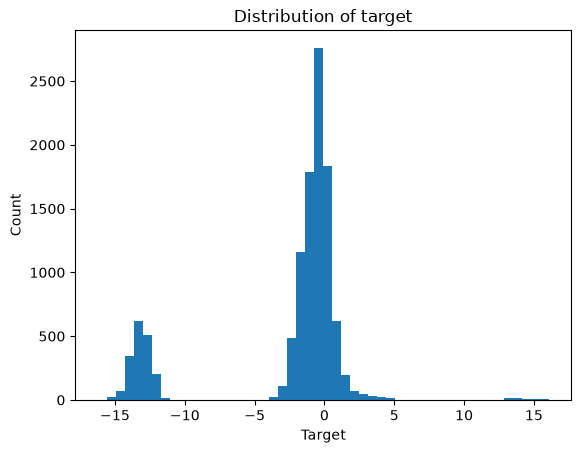

In [73]:
plt.hist(y, bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

<Axes: >

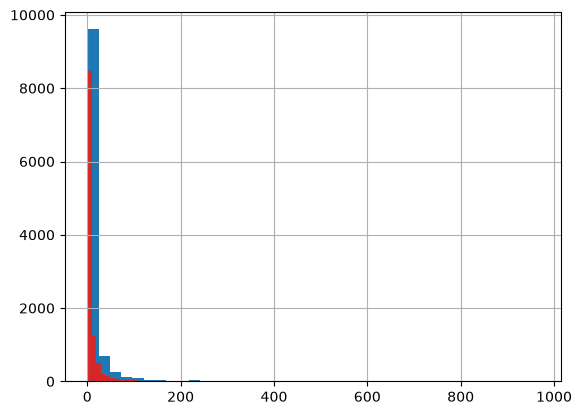

In [74]:
X["week_16_count"].hist(bins=40)
X["week_16_rel_freq"].hist(bins=40)
X["week_16_n_channels"].hist(bins=40)
X["week_16_n_videos"].hist(bins=40)

Text(0, 0.5, 'Target')

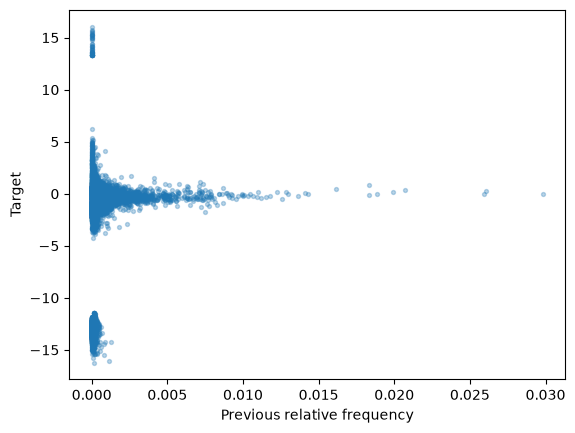

In [75]:
plt.scatter(
    X["week_16_rel_freq"],
    y,
    s=8,
    alpha=0.3
)
plt.xlabel("Previous relative frequency")
plt.ylabel("Target")

In [76]:
X.isna().sum().sort_values(ascending=False).head(20)

week_0_count                 0
n_channels_log_growth_3_2    0
n_videos_log_growth_5_4      0
n_videos_log_growth_6_5      0
n_videos_log_growth_7_6      0
n_videos_log_growth_8_7      0
n_videos_log_growth_9_8      0
n_videos_log_growth_10_9     0
n_videos_log_growth_11_10    0
n_videos_log_growth_12_11    0
n_videos_log_growth_13_12    0
n_videos_log_growth_14_13    0
n_videos_log_growth_15_14    0
n_videos_log_growth_16_15    0
n_channels_log_growth_1_0    0
n_channels_log_growth_2_1    0
n_channels_log_growth_4_3    0
n_videos_log_growth_3_2      0
n_channels_log_growth_5_4    0
n_channels_log_growth_6_5    0
dtype: int64

In [77]:
top_words = eval_df.nlargest(100, "y_true")["word"]

X_top = X.loc[top_words]
X_rest = X.drop(top_words)

top_means = X_top.mean()
rest_means = X_rest.mean()

comparison = pd.DataFrame({
    "top100_mean": top_means,
    "rest_mean": rest_means,
    "difference": top_means - rest_means,
    "ratio": top_means / (rest_means + 1e-10)
}).sort_values("difference", ascending=False)

comparison.head(30)

,top100_mean,rest_mean,difference,ratio
rel_likes_log_growth_8_7,0.340786,-0.694385,1.035171,-0.490774
rel_freq_log_growth_10_9,1.080166,0.111246,0.968920,9.709670
rel_freq_log_growth_16_15,1.506794,0.564964,0.941830,2.667062
rel_likes_log_growth_5_4,0.365841,-0.388218,0.754059,-0.942360
rel_freq_log_growth_8_7,0.255931,-0.469134,0.725065,-0.545540
rel_freq_log_growth_5_4,0.509324,-0.049843,0.559167,-10.218651
rel_likes_log_growth_10_9,0.834409,0.277942,0.556468,3.002104
rel_freq_log_growth_14_13,0.393794,-0.062589,0.456383,-6.291726
likes_log_growth_8_7,0.125928,-0.295826,0.421754,-0.425681
rel_likes_log_growth_14_13,0.433861,0.059840,0.374021,7.250384


In [78]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf,
    X,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)


/opt/anaconda3/envs/slang-env/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/slang-env/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/slang-env/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/slang-env/lib/python3.13/site-pa

In [79]:
perm.head(20)

,feature,importance
258,n_videos_mean,0.576974
251,count_max,0.253461
260,rel_freq_recent3_mean,0.115121
67,week_16_n_videos,0.085223
248,weeks_nonzero,0.031618
101,week_16_rel_freq,0.014323
267,count_slope,0.013249
16,week_16_count,0.012481
268,likes_slope,0.011275
253,rel_freq_std,0.011114
